<a href="https://colab.research.google.com/github/MElsdk-lab/Biochar_forest_estimation/blob/main/Notebook_2_Forest_Area_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# NOTEBOOK 2 — Forest Area Analysis & FAO Comparison
# University of Pittsburgh | Biochar Feedstock Methodology
# ============================================================

In [2]:
# ── CELL 1: Install Libraries ─────────────────────────────────────────────────
!pip install -q pandas matplotlib
print('✅ Libraries installed')

✅ Libraries installed


In [3]:
# ── CELL 2: clone repo if not already cloned ─────────────────────
import os
import getpass
import subprocess

if not os.path.exists('/content/Biochar_forest_estimation'):
    PAT = getpass.getpass('Enter PAT: ')
    !git config --global user.email "sdkmajd@gmail.com"
    !git config --global user.name "MElsdk-lab"
    subprocess.run(
        f'git clone https://{PAT}@github.com/MElsdk-lab/Biochar_forest_estimation.git',
        shell=True
    )

%cd /content/Biochar_forest_estimation/
!git fetch origin
!git reset --hard origin/main

DATA_folder = '/content/Biochar_forest_estimation/data/'
FIGURE_folder = '/content/Biochar_forest_estimation/figures'

print('✅ Ready')

/content/Biochar_forest_estimation
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 336 bytes | 84.00 KiB/s, done.
From https://github.com/MElsdk-lab/Biochar_forest_estimation
   cc6093f..26c89b7  main       -> origin/main
HEAD is now at 26c89b7 import GLC
✅ Ready


In [4]:
## ── CELL 3: import Libraries and results & data from GEE and FOA ─────────────────────────────────────────────────

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import numpy as np
from scipy import stats

from data_config import (build_country_lookup, FAO_LSIB_REGION, country_thresholds, state_thresholds,
                         fao_fra_2025_raw_data, FAO_name_fix,
                         americas_region, europe_region, africa_region, asia_region, near_east_region,
                         testing_sample)


print('✅ Libraries imported')
print('✅ Data config loaded')


✅ Libraries imported
✅ Data config loaded


In [5]:
# ── CELL 4: Load GEE Results ───────────────────────────────────────────────────

# --- Load country forest area ---
forest_area_all_thresholds = pd.read_csv(DATA_folder + 'forest_area_all_thresholds.csv')
forest_area_all_thresholds.rename(columns={'country_na': 'country', 'sum' :'area_Mha'}, inplace=True)
forest_area_all_thresholds.sort_values(by=['country', 'threshold'], inplace=True)
forest_area_all_thresholds = forest_area_all_thresholds.groupby(
    ['country', 'threshold'], as_index=False
)['area_Mha'].sum()

print(forest_area_all_thresholds.head())
print(f'✅ Country forest data loaded: {len(forest_area_all_thresholds)} rows')

# --- Load US state forest area ---
states_total_forest_area = pd.read_csv(DATA_folder + 'states_forest_area_all_thresholds.csv')
states_total_forest_area.sort_values(by=['state', 'threshold'], inplace=True)
states_total_forest_area = states_total_forest_area.groupby(
    ['state', 'threshold'], as_index=False
)['area_Mha'].sum()

# Save processed files
forest_area_all_thresholds.to_csv(DATA_folder + 'country_total_forest_area.csv', index=False)
states_total_forest_area.to_csv(DATA_folder + 'states_total_forest_area.csv', index=False)

# Extract Alaska and Hawaii for USA correction
alaska_state_forest_area = states_total_forest_area[states_total_forest_area['state'] == 'Alaska']
hawaii_state_forest_area  = states_total_forest_area[states_total_forest_area['state'] == 'Hawaii']

"""
Correction of USA forest area:
USA in LSIB is the 48 contiguous states.
Alaska and Hawaii are included in the Asia and Pacific / Oceania subregion in FAO.
We subtract Alaska and Hawaii from the US total to match FAO's definition.
"""

print(f'✅ State forest data loaded: {len(states_total_forest_area)} rows')


       country  threshold  area_Mha
0  Afghanistan         10  0.427305
1  Afghanistan         20  0.287657
2  Afghanistan         30  0.239637
3  Afghanistan         40  0.191961
4  Afghanistan         50  0.146759
✅ Country forest data loaded: 975 rows
✅ State forest data loaded: 250 rows


In [6]:
## ── CELL 4: establish total countries and US states results & data ──────────────────

# --- Process country data ---
# Define file paths for country forest area data
countries_files = [os.path.join(DATA_folder, f"forest_area_{i}0.csv") for i in range(1, 6)]

# Concatenate all country data files into a single DataFrame
country_total_forest_area = pd.concat([pd.read_csv(f) for f in countries_files],ignore_index=True)

# Rename columns for clarity and consistency
country_total_forest_area=country_total_forest_area.rename(columns = {'country_na' :'country', 'sum' : 'area_Mha'})
# Sort values by country and threshold
country_total_forest_area.sort_values(by= ['country', 'threshold'], ascending=True, inplace=True)
# Aggregate by country and threshold, summing area_Mha
country_total_forest_area=country_total_forest_area.groupby(['country', 'threshold'])['area_Mha'].sum().reset_index()

# Save processed country data to a CSV file
country_total_forest_area.to_csv(DATA_folder + 'country_total_forest_area.csv', index=False)

print(f'✅ Forest data loaded and saved with {int(len(country_total_forest_area)/len(country_thresholds))} rows')

# --- Process US state data ---
# Define file paths for US state forest area data
states_files = [os.path.join(DATA_folder, f"states_forest_area_{i}0.csv") for i in range(1, 6)]

# Concatenate all state data files into a single DataFrame
states_total_forest_area = pd.concat([pd.read_csv(f) for f in states_files], ignore_index=True)

# Rename columns for clarity and consistency
states_total_forest_area = states_total_forest_area.rename(columns={'NAME': 'state', 'sum': 'area_Mha'})
# Sort values by state and threshold
states_total_forest_area.sort_values(by=['state', 'threshold'], ascending=True, inplace=True)
# Aggregate by state and threshold, summing area_Mha
states_total_forest_area = states_total_forest_area.groupby(['state', 'threshold'])['area_Mha'].sum().reset_index()
# Save processed state data to a CSV file
states_total_forest_area.to_csv(DATA_folder + 'states_total_forest_area.csv', index=False)

# Extract Alaska and Hawaii data for special handling
alaska_state_forest_area = states_total_forest_area[states_total_forest_area['state' ]== 'Alaska']
hawaii_state_forest_area = states_total_forest_area[states_total_forest_area['state' ]== 'Hawaii']

"""
correction of USA forest area since
USA is  considered as a  block of 48 contiguous states referred to as the conterminous states forms a belt of 7 828 016 km2 across the continent from the Atlantic Ocean to the Pacific Ocean
Alaska and Hawaii are included in the Oceania and Pacific region

even in LSIB dataset the US is about 48 contiguous states ( confirmed by showing the layer on the map)
"""


print(f'✅ Forest data loaded and saved with {int(len(states_total_forest_area)/len(state_thresholds))} rows')


✅ Forest data loaded and saved with 195 rows
✅ Forest data loaded and saved with 50 rows


In [7]:
# ── CELL 5: Adjust USA Forest Area ───────────────────────────────────────────
usa_forest_area_gee = country_total_forest_area[country_total_forest_area['country'] == 'United States']

print(usa_forest_area_gee)
# Merge on threshold so subtraction is aligned
usa = usa_forest_area_gee.set_index('threshold')
alaska = alaska_state_forest_area.set_index('threshold').rename(columns={'area_Mha': 'alaska_area_Mha'})
hawaii = hawaii_state_forest_area.set_index('threshold').rename(columns={'area_Mha': 'hawaii_area_Mha'})

merge = usa.merge(alaska, left_on='threshold', right_on='threshold').merge(hawaii, left_on='threshold', right_on='threshold')
#substract

merge['area_Mha'] = merge['area_Mha'] + (merge['alaska_area_Mha'] + merge['hawaii_area_Mha'])

merge=merge.drop(columns=['state_x', 'alaska_area_Mha', 'state_y','hawaii_area_Mha'])
merge = merge.reset_index()  # ADD THIS LINE

1
# Remove old US rows
country_total_forest_area_no_us = country_total_forest_area[country_total_forest_area['country'] != 'United States']

# Add adjusted US rows back
country_total_forest_area_cor= pd.concat([country_total_forest_area_no_us, merge], ignore_index=True)

country_total_forest_area_cor.to_csv(DATA_folder + 'country_total_forest_area_cor.csv', index=False)
print(f'✅ Adjusted USA forest area')

usa_forest_area_gee_cor = country_total_forest_area_cor[country_total_forest_area_cor['country'] == 'United States']

           country  threshold    area_Mha
925  United States         10  258.339230
926  United States         20  242.557391
927  United States         30  229.310219
928  United States         40  218.853025
929  United States         50  207.240547
✅ Adjusted USA forest area


In [8]:
## ── CELL 5 : build region and subregion info for countries in 'country_total_forest_area' file by the intermidate of FAO_LSIB_REGION   ─────────────────────────────────────────────────
# 1. Generate the lookup dictionary
country_lookup = build_country_lookup(FAO_LSIB_REGION)

# 2. Create the new columns by looking up each country name
# we could actualy transform the country_lookup from a dictionary to a data frame then merge with df bsed onthe country name
country_total_forest_area_cor['region'] = country_total_forest_area_cor['country'].map(lambda l: country_lookup.get(l, {}).get('region', 'unknown'))
country_total_forest_area_cor['subregion'] = country_total_forest_area_cor['country'].map(lambda l: country_lookup.get(l, {}).get('subregion', 'unknown'))

print(f"✅countries are affilited to regions and subregions")

✅countries are affilited to regions and subregions


In [9]:
# ── CELL 6: Merge GEE results with FAO 2000 ──────────────
FAO_fra_2025_data = pd.read_csv(DATA_folder + 'fao_fra_2025_data.csv')

FAO_forest_area_country_2000 = FAO_fra_2025_data[['country', '2000_area_Mha']].rename(columns={'2000_area_Mha': 'FAO_2000_Mha'})

gee_fao_comparison = country_total_forest_area_cor.merge(FAO_forest_area_country_2000, on='country', how='left')

#print(gee_fao_comparison.head(40))

print(f"Results from GEE has {len(country_total_forest_area)}")

print(f"FAO has {len(FAO_forest_area_country_2000)}")
#counting th number of countries with data; since there is 5  different thresholds, nunique returns the number of unique values in the selected column:
print(f'Total countries: {gee_fao_comparison["country"].nunique()}')

# if mising, unique show the the values of unique values

missing = gee_fao_comparison[gee_fao_comparison['FAO_2000_Mha'].isna()]['country'].unique()

print(f"Total countries with no FAO match: {len(missing)}")
print('GEE results are merged with FAO 2000 ')

usa_forest_area_gee_fao = gee_fao_comparison[gee_fao_comparison['country'] == 'United States']
print(usa_forest_area_gee_fao)

Results from GEE has 975
FAO has 195
Total countries: 195
Total countries with no FAO match: 0
GEE results are merged with FAO 2000 
           country  threshold    area_Mha    region      subregion  \
970  United States         10  315.888204  Americas  North America   
971  United States         20  296.005725  Americas  North America   
972  United States         30  280.179830  Americas  North America   
973  United States         40  265.610296  Americas  North America   
974  United States         50  244.861741  Americas  North America   

     FAO_2000_Mha  
970       303.536  
971       303.536  
972       303.536  
973       303.536  
974       303.536  


In [10]:
# ── CELL 7: aggregate by subregion and region. ──────────────

# --- Aggregate data by subregion ---
# Group by subregion and threshold, summing forest area and FAO data
gee_fao_comparison_subregion = gee_fao_comparison.groupby(['subregion', 'threshold']).agg(
    region=('region', 'first'), # Ensure 'region' is carried over
    subregion_total_forest_area=('area_Mha', 'sum'),
    FAO_2000_Mha=('FAO_2000_Mha', 'sum')
).reset_index()


# --- Add Alaska and Hawaii forest area to the Pacific subregion ---
pacific_subregion = gee_fao_comparison_subregion[gee_fao_comparison_subregion['subregion'] == 'Pacific Region'].copy()
# Merge pacific subregion data with Alaska and Hawaii data based on threshold
merged_pacific_subregion = pacific_subregion.merge(alaska, left_on='threshold', right_on='threshold').merge(hawaii, left_on='threshold', right_on='threshold')
# Add Alaska and Hawaii forest areas to the Pacific subregion total
merged_pacific_subregion['subregion_total_forest_area'] = merged_pacific_subregion['subregion_total_forest_area'] + (merged_pacific_subregion['alaska_area_Mha'] + merged_pacific_subregion['hawaii_area_Mha'])
# Drop auxiliary state columns after merge
merged_pacific_subregion = merged_pacific_subregion.drop(columns=['state_x', 'alaska_area_Mha', 'state_y','hawaii_area_Mha'])


# --- Aggregate data by region ---
# Group by region and threshold, summing subregion total forest area and FAO data
gee_fao_comparison_region = gee_fao_comparison_subregion.groupby(['region', 'threshold']).agg(
    region_total_forest_area=('subregion_total_forest_area', 'sum'),
    FAO_2000_Mha=('FAO_2000_Mha', 'sum')
).reset_index()

# --- Aggregate data globally (world level) ---
# Group by threshold, summing region total forest area and FAO data
gee_fao_comparison_world = gee_fao_comparison_region.groupby(['threshold']).agg(
    world_total_forest_area=('region_total_forest_area', 'sum'),
    FAO_2000_Mha=('FAO_2000_Mha', 'sum')
).reset_index()


# --- Calculate deviation between GEE and FAO for countries ---
gee_fao_comparison['deviation_Mha'] = gee_fao_comparison['area_Mha'] - gee_fao_comparison['FAO_2000_Mha']
gee_fao_comparison['deviation_%'] = abs(gee_fao_comparison['deviation_Mha'] / gee_fao_comparison['FAO_2000_Mha']) * 100
gee_fao_comparison.replace([np.inf, -np.inf], np.nan, inplace=True)

clean_dev = gee_fao_comparison.replace([float('inf'), float('-inf')], float('nan'))

# --- Calculate deviation for subregions ---
gee_fao_comparison_subregion['deviation_Mha'] = gee_fao_comparison_subregion['subregion_total_forest_area'] - gee_fao_comparison_subregion['FAO_2000_Mha']
gee_fao_comparison_subregion['deviation_%'] = abs(gee_fao_comparison_subregion['deviation_Mha'] / gee_fao_comparison_subregion['FAO_2000_Mha']) * 100

# --- Calculate deviation for regions ---
gee_fao_comparison_region['deviation_Mha'] = gee_fao_comparison_region['region_total_forest_area'] - gee_fao_comparison_region['FAO_2000_Mha']
gee_fao_comparison_region['deviation_%'] = abs(gee_fao_comparison_region['deviation_Mha'] / gee_fao_comparison_region['FAO_2000_Mha']) * 100

# --- Calculate deviation for world total ---
gee_fao_comparison_world['deviation_Mha'] = gee_fao_comparison_world['world_total_forest_area'] - gee_fao_comparison_world['FAO_2000_Mha']
gee_fao_comparison_world['deviation_%'] = abs(gee_fao_comparison_world['deviation_Mha'] / gee_fao_comparison_world['FAO_2000_Mha']) * 100

# --- Save aggregated and comparison results to CSV files ---
gee_fao_comparison.to_csv(DATA_folder + 'gee_fao_comparison.csv', index=False)
gee_fao_comparison_subregion.to_csv(DATA_folder + 'gee_fao_comparison_subregion.csv', index=False)
gee_fao_comparison_region.to_csv(DATA_folder + 'gee_fao_comparison_region.csv', index=False)
gee_fao_comparison_world.to_csv(DATA_folder + 'gee_fao_comparison_world.csv', index=False)

print('✅ Results are aggregated by subregion and region')


✅ Results are aggregated by subregion and region


In [11]:
# ── CELL 8: Calculate Percentiles and Bin Forest Area ───────────────

# --- Calculate FAO 2000 forest area percentiles ---
percentiles = [25, 50, 60, 70, 80, 90, 95]
FAO_2000_percentiles = np.percentile(FAO_forest_area_country_2000['FAO_2000_Mha'],percentiles)

# Create a dictionary for easy access to percentile values
FAO_2000_percentiles_dict = {f'p{i}': round(v, 1) for i, v in zip(percentiles, FAO_2000_percentiles)}

# Extract specific percentile values for binning
x_p25 = int(FAO_2000_percentiles_dict['p25'])
x_p50 = int(FAO_2000_percentiles_dict['p50'])
x_p60 = int(FAO_2000_percentiles_dict['p60'])
x_p70 = int(FAO_2000_percentiles_dict['p70'])
x_p80 = int(FAO_2000_percentiles_dict['p80'])
x_p90 = int(FAO_2000_percentiles_dict['p90'])
x_p95 = int(FAO_2000_percentiles_dict['p95'])

# Print the calculated percentile information
for i in percentiles:
  key = f'p{i}'
  print(f'{i}% of countries have less than {float(FAO_2000_percentiles_dict[key])} Mha of forest')

# --- Divide forest area into bins and assign labels/colors ---
FAO_forest_area_country_2000_bins = FAO_forest_area_country_2000.copy()

# Define bins based on calculated percentiles
bins= pd.cut(FAO_forest_area_country_2000_bins['FAO_2000_Mha'], bins=[0,x_p60, x_p90, np.inf], labels = ['Low (< 4 Mha)', 'Medium (4-37 Mha)', 'High (> 37 Mha)'])


# Define colors for each bin category
colors = {'Low (< 4 Mha)': '#4C9BE8',
          'Medium (4-37 Mha)' : '#F4A83A',
          'High (> 37 Mha)': '#F44336'
          }

# Assign bins to the DataFrame
FAO_forest_area_country_2000_bins['bin'] = bins

# Save the binned data to a CSV file
FAO_forest_area_country_2000_bins.to_csv(DATA_folder + 'FAO_forest_area_country_2000_bins.csv', index=False)

print(f'Countries remaining: {len(FAO_forest_area_country_2000_bins)}')


25% of countries have less than 0.4 Mha of forest
50% of countries have less than 2.6 Mha of forest
60% of countries have less than 4.0 Mha of forest
70% of countries have less than 8.2 Mha of forest
80% of countries have less than 16.0 Mha of forest
90% of countries have less than 37.3 Mha of forest
95% of countries have less than 70.9 Mha of forest
Countries remaining: 195


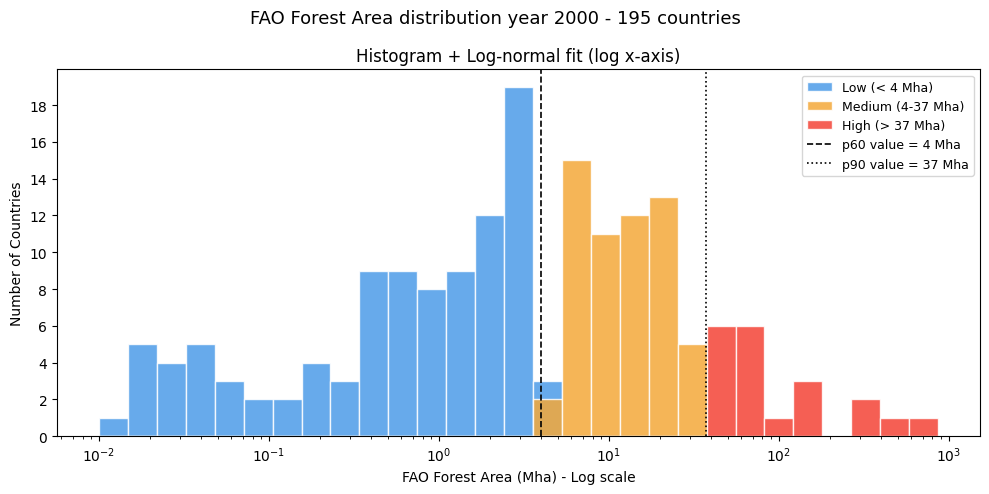

In [12]:
# ── CELL 9: Plot FAO Forest Area Distribution ───────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

fig.suptitle('FAO Forest Area distribution year 2000 - 195 countries', fontsize=13)

x_values = FAO_forest_area_country_2000['FAO_2000_Mha'].values

# --- Fit log-normal on log of values ---
# Calculate the natural logarithm of non-zero forest area values for log-normal fitting.
log_x_values = np.log10(x_values[x_values > 0])

# Calculate the mean and standard deviation of the log-transformed values.
mu, std = log_x_values.mean(), log_x_values.std()

# --- Plot 1: Histogram (log x-axis) + log-normal curve ---
# Iterate through the defined bin labels and their corresponding colors.
stats_bins = []
for bin_label, bin_color in colors.items():
    # Select a subset of data for the current bin.
    subset = FAO_forest_area_country_2000_bins[FAO_forest_area_country_2000_bins['bin'] == bin_label]['FAO_2000_Mha']

    # Plot a histogram for the current bin's data.
    ax.hist(subset,
            bins= np.logspace(np.log10(0.01), np.log10(x_values.max() + 50),30),
            color = bin_color, edgecolor='white', alpha=0.85, label=bin_label)


# Log-normal curve

# Add a vertical dashed line at the 60th percentile value.
ax.axvline(x_p60, color = 'black', linestyle='--', linewidth = 1.2,  label = f'p60 value = {x_p60} Mha')
# Add a vertical dotted line at the 90th percentile value.
ax.axvline(x_p90, color = 'black', linestyle=':', linewidth = 1.2, label = f'p90 value = {x_p90} Mha')

# Set the x-axis to a logarithmic scale.
ax.set_xscale('log')
# Label the x-axis.
ax.set_xlabel('FAO Forest Area (Mha) - Log scale')
# Label the y-axis.
ax.set_ylabel('Number of Countries')
# Set the title of the plot.
ax.set_title('Histogram + Log-normal fit (log x-axis)')
# Display the legend.
ax.legend(fontsize = 9)
# Ensure y-axis ticks are integers.
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

"""
ax2 = ax.twinx()  # creates a second y-axis sharing the same x-axis

x_range = np.logspace(np.log10(0.01), np.log10(x_values.max() + 50), 300)
pdf = stats.lognorm.pdf(x_range, s=std, scale=10**mu)
ax2.plot(x_range, pdf, color='black', linewidth=2, linestyle='--', label='Log-normal fit')
ax2.set_ylabel('Density', color='black')
ax2.tick_params(axis='y', labelcolor='black')

"""

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
#l ines2, labels2 = ax2.get_legend_handles_labels()
#ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

# Adjust layout to prevent labels from overlapping.
plt.tight_layout()
# Save the figure to the specified folder with high DPI and a tight bounding box.
plt.savefig(FIGURE_folder + '/forest_area_frequency_bins.svg', dpi=300, bbox_inches='tight')
# Display the plot.
plt.show()

FAO consistently underestimates: 74 countries
FAO consistently overestimates: 66 countries
mixed countries: 55 countries


/tmp/ipykernel_35257/2761776785.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_bins_estimation = gee_fao_comparison_bins_estimation.groupby(['bin', 'estimation'])['country'].nunique()


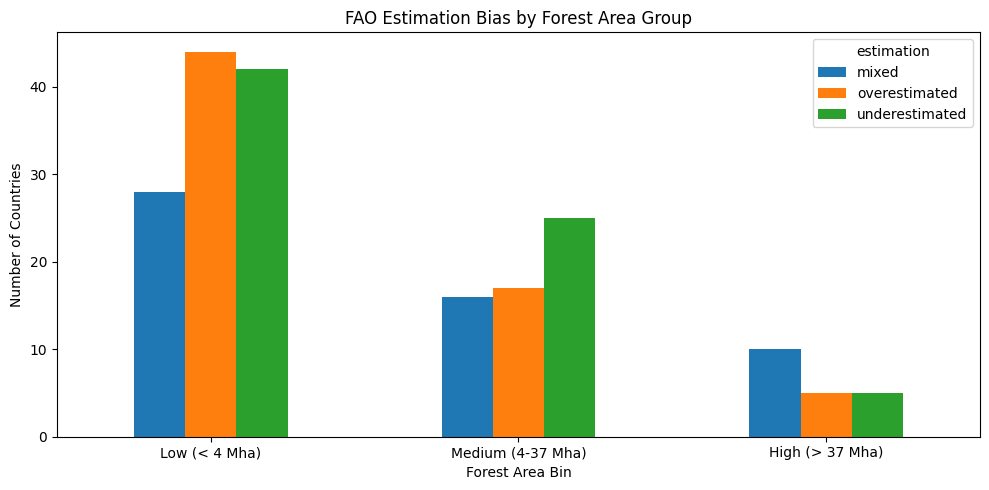

In [13]:
# ── CELL 10: Analyze FAO Estimation Bias ──────────────────
# --- Merge GEE-FAO comparison data with bin information ---
# Merge the GEE-FAO comparison data with the forest area bin information based on 'country'.
gee_fao_comparison_bins = gee_fao_comparison.merge(FAO_forest_area_country_2000_bins[['country', 'bin']], on= ['country'], how='left')
# Save the merged DataFrame to a CSV file.
gee_fao_comparison_bins.to_csv(DATA_folder + 'gee_fao_comparison_bins.csv', index=False)


# --- Analyze FAO estimation bias (underestimated, overestimated, mixed) ---
# Group by country to analyze deviation in Mha.
estimation = gee_fao_comparison.groupby('country')['deviation_Mha']
# Identify countries where FAO consistently underestimates (deviation_Mha is always positive).
underestimated = gee_fao_comparison.groupby('country')['deviation_Mha'].apply(lambda x: (x > 0).all()).reset_index(name='FAO_underestimates')
# Identify countries where FAO consistently overestimates (deviation_Mha is always negative).
overestimated = gee_fao_comparison.groupby('country')['deviation_Mha'].apply(lambda x: (x < 0).all()).reset_index(name='FAO_overestimates')

print(f"FAO consistently underestimates: {underestimated['FAO_underestimates'].sum()} countries")
print(f"FAO consistently overestimates: {overestimated['FAO_overestimates'].sum()} countries")
print(f"mixed countries: {len(estimation) - underestimated['FAO_underestimates'].sum() - overestimated['FAO_overestimates'].sum()} countries")

# Merge estimation flags back into the comparison DataFrame.
gee_fao_comparison_bins_estimation = gee_fao_comparison_bins.merge(underestimated[['country', 'FAO_underestimates']], on= ['country'], how='left')
gee_fao_comparison_bins_estimation = gee_fao_comparison_bins_estimation.merge(overestimated[['country', 'FAO_overestimates']],  on= ['country'], how='left')

# Determine 'mixed' estimation cases (neither consistently underestimated nor overestimated).
gee_fao_comparison_bins_estimation['mixed'] = (~gee_fao_comparison_bins_estimation['FAO_underestimates']) & (~gee_fao_comparison_bins_estimation['FAO_overestimates'])

# Define conditions and choices for categorizing estimation type.
conditions = [
    gee_fao_comparison_bins_estimation['FAO_underestimates'],
    gee_fao_comparison_bins_estimation['FAO_overestimates'],
    gee_fao_comparison_bins_estimation['mixed']
]

choices = ['underestimated', 'overestimated', 'mixed']

gee_fao_comparison_bins_estimation['estimation'] = np.select(conditions, choices, default='')

# Drop intermediate flags.
gee_fao_comparison_bins_estimation = gee_fao_comparison_bins_estimation.drop(columns=['FAO_underestimates', 'FAO_overestimates', 'mixed'])

gee_fao_comparison_bins_estimation.to_csv(DATA_folder + 'gee_fao_comparison_bins_estimation.csv', index=False)


# --- Summarize and plot estimation bias by forest area bin ---
# Group by 'bin' and 'estimation' to count unique countries in each category.
country_bins_estimation = gee_fao_comparison_bins_estimation.groupby(['bin', 'estimation'])['country'].nunique()
# Save the summarized data to a CSV file.
country_bins_estimation.to_csv(DATA_folder + 'country_bins_estimation.csv', index= True)

# Unstack the data to prepare for plotting.
country_bins_estimation.unstack()

# Create a figure and axes for the bar plot.
fig, ax = plt.subplots(figsize=(10, 5))
# Plot the unstacked data as a bar chart.
country_bins_estimation.unstack().plot(kind='bar', ax=ax)

# Label the x-axis.
ax.set_xlabel('Forest Area Bin')
# Label the y-axis.
ax.set_ylabel('Number of Countries')
# Set the title of the plot.
ax.set_title('FAO Estimation Bias by Forest Area Group')
# Keep x-axis labels horizontal for readability.
ax.tick_params(axis='x', rotation=0)


# Adjust layout to prevent labels from overlapping.
plt.tight_layout()
# Save the figure to the specified folder with high DPI and a tight bounding box.
plt.savefig(FIGURE_folder + '/forest_area_country_bins_estimation.svg', dpi=300, bbox_inches='tight')
# Display the plot.
plt.show()


/tmp/ipykernel_35257/42598660.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = gee_fao_comparison_bins.groupby(['bin', 'threshold']).get_group((bin_label, threshold))


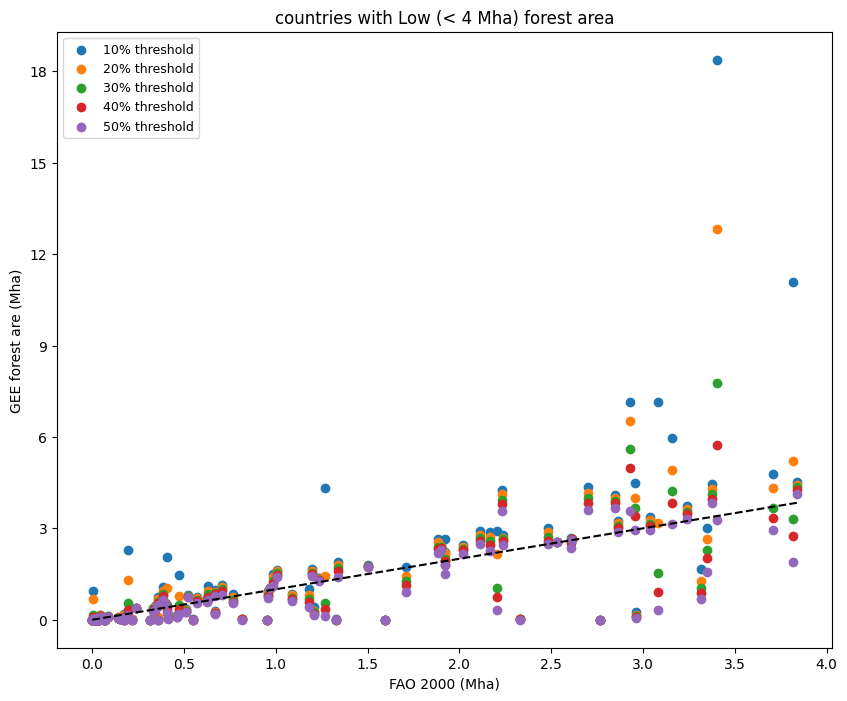

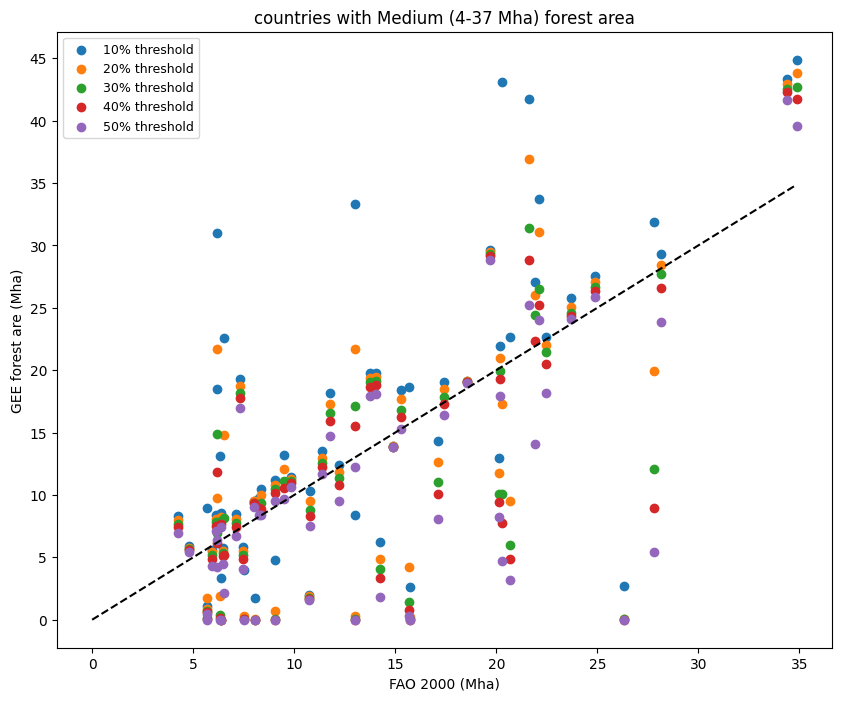

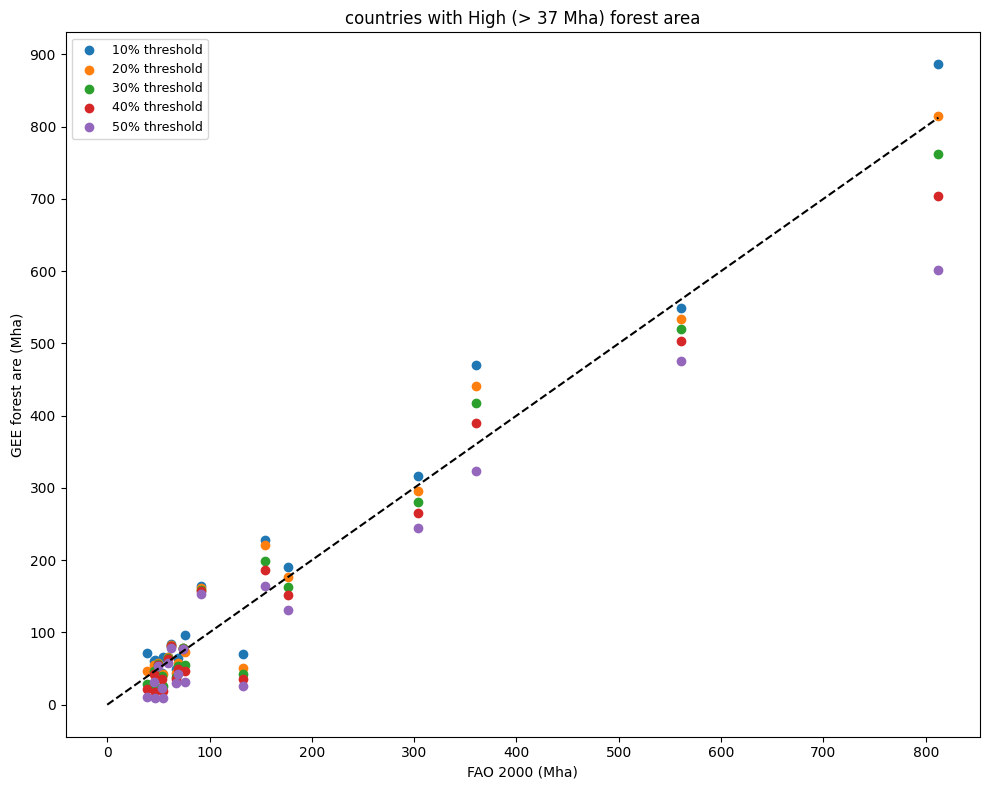

In [14]:
# ── CELL 10: Compare GEE and FAO Forest Area by Bin and Threshold ───────────────────────────

# Initialize an empty list to store statistics.
gee_fao_stats = []
# Define labels for forest area bins.
bin_labels = ['Low (< 4 Mha)', 'Medium (4-37 Mha)', 'High (> 37 Mha)']
# Iterate through each bin label.
for bin_label in  bin_labels:
    # Create a new figure and axes for each bin.
    fig, ax = plt.subplots(figsize=(10, 8))

    # Iterate through each country threshold.
    for threshold in country_thresholds:
        # Filter data for the current bin and threshold.
        df = gee_fao_comparison_bins.groupby(['bin', 'threshold']).get_group((bin_label, threshold))
        # Extract FAO 2000 forest area values, dropping NaN values.
        x_values = df['FAO_2000_Mha'].dropna()
        # Extract GEE forest area values, dropping NaN values.
        y_values = df['area_Mha'].dropna()
        # Plot scatter points for current threshold.
        ax.scatter(x_values, y_values, label=f'{threshold}% threshold')
        # Perform linear regression to calculate R-squared and other stats.
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_values, y_values)
        #print(f'in {bin_label} /n for threshold {threshold}%, R² = {r_value**2:.3f}, average deviation = {df["deviation_%"].median():.2f}%')
        # Append calculated statistics to the list.
        gee_fao_stats.append({'bin': bin_label, 'threshold': threshold, 'r_squared': round(r_value**2, 3), 'average deviation': round(df["deviation_%"].median(), 1)})


    # Determine the maximum value for the 1:1 line.
    match_max=max(df['FAO_2000_Mha'])
    # Plot the 1:1 reference line.
    ax.plot([0, match_max], [0,match_max], linestyle = '--', color = 'black')

    # Display the legend.
    ax.legend(fontsize = 9)
    # Set x-axis label.
    ax.set_xlabel('FAO 2000 (Mha)')
    # Set y-axis label.
    ax.set_ylabel('GEE forest are (Mha)')
    # Set plot title.
    ax.set_title(f'countries with {bin_label} forest area')
    # Ensure y-axis ticks are integers.
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))


# Adjust layout to prevent labels from overlapping.
plt.tight_layout()
# Save the figure to the specified folder.
plt.savefig(FIGURE_folder + '/gee_fao_country_bins.svg', dpi=300, bbox_inches='tight')
# Display the plot.
plt.show()

# Create a DataFrame from the collected statistics.
gee_fao_stats_df = pd.DataFrame(gee_fao_stats)
# Save the statistics DataFrame to a CSV file.
gee_fao_stats_df.to_csv(DATA_folder + 'gee_fao_stats.csv', index=False)

#print(gee_fao_stats_df)


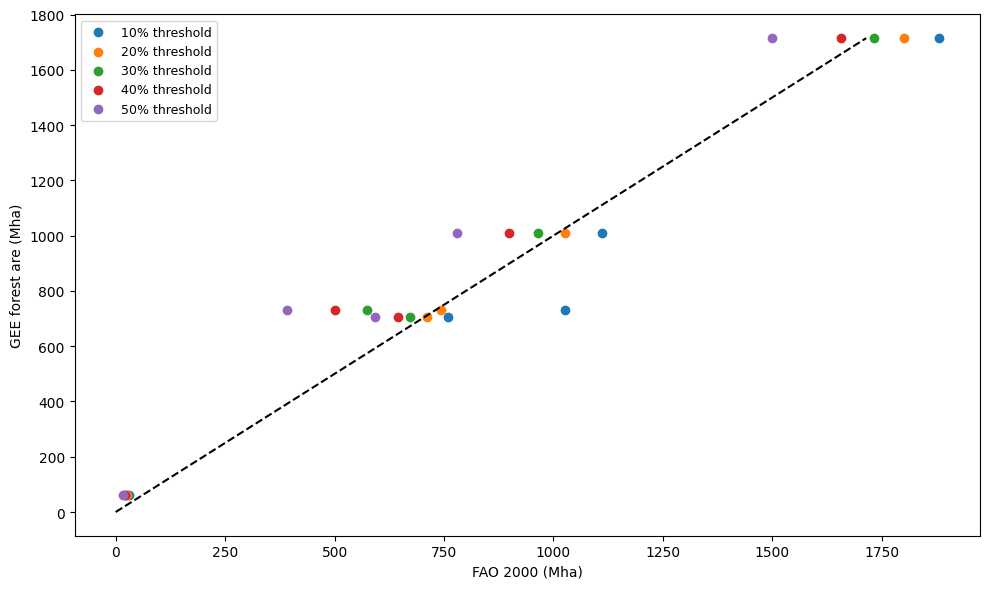

In [15]:
# ── CELL 11: Plot GEE vs FAO by Region ───────────────────────────
# This cell plots the GEE forest area against FAO 2000 forest area, categorized by region.
# The goal is to visually compare the two datasets at a regional level.

# Get the number of unique regions.
nb_region = gee_fao_comparison_region['region'].nunique()
# Get a list of unique regions.
regions = gee_fao_comparison_region['region'].unique()

# Define colors for each region for consistent plotting.
region_colors = {
    'Africa': '#E05C5C',
    'Americas': '#4C9BE8',
    'Asia and the Pacific': '#F4A83A',
    'Europe': '#4CAF50',
    'Near East': '#9C27B0'
}

# Define markers for each threshold value.
threshold_markers = {
    10: 'o',   # circle
    20: 's',   # square
    30: '^',   # triangle
    40: 'D',   # diamond
    50: 'P'    # plus
}

# Create a figure and axes for the plot.
fig, ax = plt.subplots(figsize=(10, 6))

# Iterate through each threshold to plot the data.
for threshold in country_thresholds:
  # Filter the data for the current threshold.
  df = gee_fao_comparison_region[gee_fao_comparison_region['threshold'] == threshold]
  # Extract FAO 2000 Mha for x-axis.
  x_values = df['region_total_forest_area']
  # Extract GEE forest area Mha for y-axis.
  y_values = df['FAO_2000_Mha']
  # Plot scatter points with a label for the threshold.
  ax.scatter(x_values, y_values, label=f'{threshold}% threshold')
  # Perform linear regression (though the results are not explicitly used for plotting here).
  slope, intercept, r_value, p_value, std_err = stats.linregress(x_values, y_values)

# Set x-axis label.
ax.set_xlabel('FAO 2000 (Mha)')
# Set y-axis label.
ax.set_ylabel('GEE forest are (Mha)')
# Display the legend.
ax.legend(fontsize = 9)
# Ensure y-axis ticks are integers.
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
# Determine the maximum value for the 1:1 line based on FAO data.
match_max=max(gee_fao_comparison_region['FAO_2000_Mha'])

# Plot the 1:1 reference line.
ax.plot([0, match_max], [0,match_max], linestyle = '--', color = 'black')

# Adjust layout to prevent labels from overlapping.
plt.tight_layout()
# Save the figure to the specified folder.
plt.savefig(FIGURE_folder + '/gee_fao_regions_threshold_basic.svg', dpi=300, bbox_inches='tight')
# Display the plot.
plt.show()

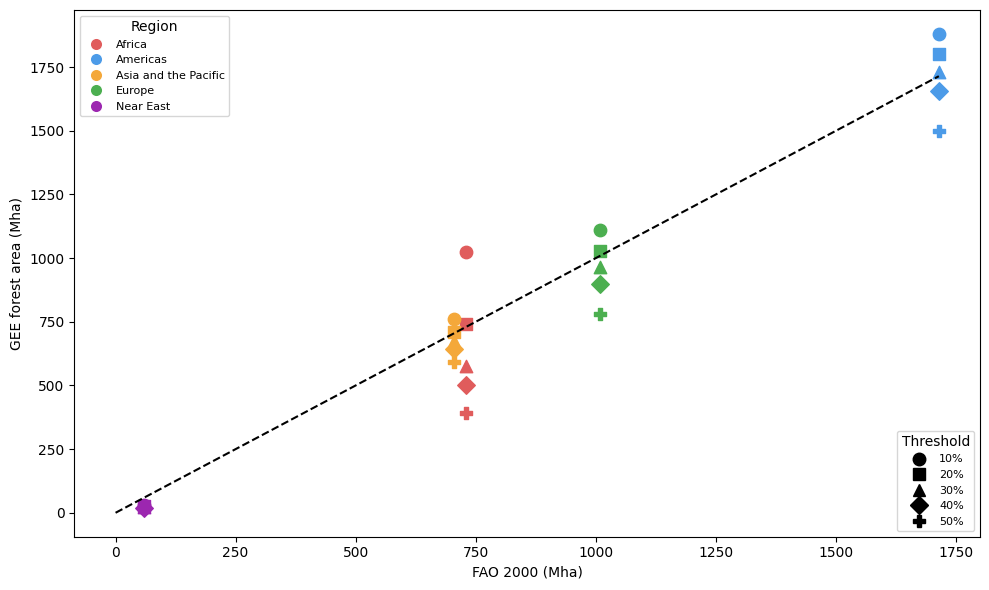

In [16]:
# ── CELL 12: Plot GEE vs FAO by Region and Threshold ───────────────────────────
# This cell generates a scatter plot to compare GEE and FAO forest area, distinguishing data points by region (color) and threshold (marker shape).

# Create a figure and axes for the plot.
fig, ax = plt.subplots(figsize=(10, 6))

# Initialize a list to store regression results for regions and thresholds.
regions_thresholds_reg = []
# Iterate through each unique region.
for region in regions:
    # Iterate through each country threshold.
    for threshold in country_thresholds:
        # Filter the DataFrame to get data for the current region and threshold.
        df = gee_fao_comparison_region[
            (gee_fao_comparison_region['region'] == region) &
            (gee_fao_comparison_region['threshold'] == threshold)
        ]
        # Perform linear regression to get r_value for each segment.
        x_values = df['FAO_2000_Mha']
        y_values = df['region_total_forest_area']
        # Check if there are enough data points for regression (at least 2).
        if len(x_values) > 1: # Need at least 2 points for linregress
            # Perform linear regression.
            slope, intercept, r_value, p_value, std_err = stats.linregress(x_values, y_values)
            # Append the threshold and R-squared value to the list.
            regions_thresholds_reg.append({'threshold': threshold, 'r_squared': round(r_value**2, 3)})

        # Plot scatter points using region color and threshold marker.
        ax.scatter(df['FAO_2000_Mha'], df['region_total_forest_area'],
                   color=region_colors[region],
                   marker=threshold_markers[threshold],
                   s=80)


# --- Legend 1: regions (color) ---
# Create custom legend handles for regions based on defined colors.
region_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=9, label=region)
                  for region, color in region_colors.items()]

# --- Legend 2: thresholds (marker shape) ---
# Create custom legend handles for thresholds based on defined markers.
threshold_handles = [Line2D([0], [0], marker=marker, color='black', linestyle='None', markersize=9, label=f'{t}%')
                     for t, marker in threshold_markers.items()]

# --- Add both legends ---
# Add the region legend to the plot.
legend1 = ax.legend(handles=region_handles, title='Region', fontsize=8, loc='upper left')
# Add the first legend to the figure.
ax.add_artist(legend1)
# Add the threshold legend to the plot.
ax.legend(handles=threshold_handles, title='Threshold', fontsize=8, loc='lower right')

# Determine the maximum value for the 1:1 line based on FAO data.
match_max = max(gee_fao_comparison_region['FAO_2000_Mha'])
# Plot the 1:1 reference line.
ax.plot([0, match_max], [0, match_max], linestyle='--', color='black', label='1:1 line')
# Set x-axis label.
ax.set_xlabel('FAO 2000 (Mha)')
# Set y-axis label.
ax.set_ylabel('GEE forest area (Mha)')
# Ensure y-axis ticks are integers.
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
# Adjust layout to prevent labels from overlapping.
plt.tight_layout()
# Save the figure to the specified folder.
plt.savefig(FIGURE_folder + '/gee_fao_regions.svg', dpi=300, bbox_inches='tight')
# Display the plot.
plt.show()

for threshold 10%, R² = 0.980, average deviation = 38.70%
for threshold 20%, R² = 0.978, average deviation = 35.77%
for threshold 30%, R² = 0.977, average deviation = 34.54%
for threshold 40%, R² = 0.974, average deviation = 34.87%
for threshold 50%, R² = 0.965, average deviation = 34.76%


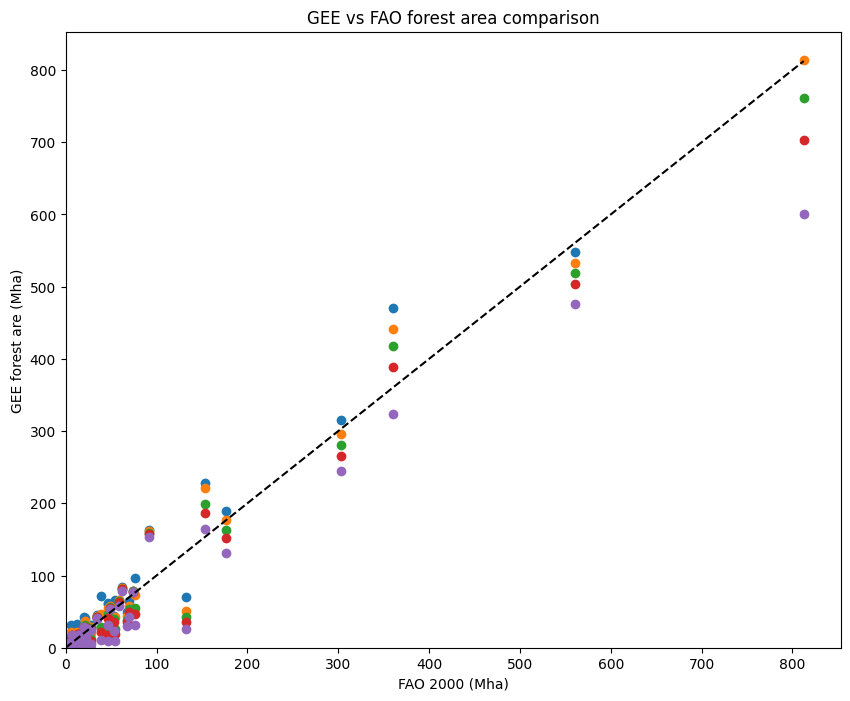

In [17]:
# ── CELL 13: Plot GEE vs FAO (All Countries) ──────────────
# This cell generates a scatter plot comparing GEE forest area with FAO 2000 forest area for all countries, showing data points for different thresholds.

# Create the figure and axes for the plot.
fig, ax = plt.subplots(figsize=(10, 8))
# Set the x-axis limit slightly beyond the maximum FAO 2000 value.
plt.xlim(right = 1.05 *max(gee_fao_comparison['FAO_2000_Mha']))
# Set the y-axis limit slightly beyond the maximum GEE forest area value.
plt.ylim(top = 1.05 *max(gee_fao_comparison['FAO_2000_Mha']))

# Plot the data points for each threshold.
for threshold in country_thresholds:
  # Filter the main comparison DataFrame for the current threshold.
  df =gee_fao_comparison[gee_fao_comparison['threshold'] == threshold]
  # Filter the cleaned deviation DataFrame for the current threshold.
  cleandev_df= clean_dev[clean_dev['threshold'] == threshold]
  # Extract FAO 2000 forest area values, dropping NaN values.
  x_values = df['FAO_2000_Mha'].dropna()   #check where are the nan in both column
  # Extract GEE forest area values, dropping NaN values.
  y_values = df['area_Mha'].dropna()

  # Plot scatter points with a label indicating the threshold.
  ax.scatter(x_values, y_values, label=f'GEE {threshold}%')
  # Perform linear regression to calculate R-squared and other statistics.
  slope, intercept, r_value, p_value, std_err = stats.linregress(x_values, y_values)
  # Print R-squared and average deviation for the current threshold.
  print(f'for threshold {threshold}%, R² = {r_value**2:.3f}, average deviation = {cleandev_df["deviation_%"].median():.2f}%')


# Add labels, limits and title to the plot.
ax.set_xlabel('FAO 2000 (Mha)')
ax.set_ylabel('GEE forest are (Mha)')
ax.set_title('GEE vs FAO forest area comparison')

# Determine the maximum value for the 1:1 line based on FAO data.
match_max=max(gee_fao_comparison['FAO_2000_Mha'])

# Plot the 1:1 reference line.
ax.plot([0, match_max], [0,match_max], linestyle = '--', color = 'black')

# Save the plot to the specified folder.
plt.savefig(FIGURE_folder + '/gee_fao_all_countries.svg', dpi=300, bbox_inches='tight')
# Display the plot.
plt.show()

In [18]:
glc_total_forest_area_all_countries = pd.read_csv(DATA_folder + 'glc_total_forest_area_all_countries.csv')
glc_total_forest_area_all_countries.rename(columns={'area_Mha':'GLC_Mha'}, inplace=True)
glc_total_forest_area_all_countries.groupby(
    ['country'], as_index=False
)['GLC_Mha'].sum()
print(glc_total_forest_area_all_countries.head())
glc_total_forest_area_all_countries.to_csv(DATA_folder + 'glc_total_forest_area_all_countries.csv', index=False)

    country    GLC_Mha
0      Chad   3.682123
1    Malawi   5.013165
2    Zambia  46.878865
3  Zimbabwe  20.303776
4  Botswana   2.750309


In [19]:
gee_fao_glc_comparison = gee_fao_comparison.merge(glc_total_forest_area_all_countries, on = 'country', how = 'left')

gee_fao_glc_comparison['deviation_GLC_Mha'] = gee_fao_glc_comparison['area_Mha'] - gee_fao_glc_comparison['GLC_Mha']
gee_fao_glc_comparison['deviation_GLC_%'] = abs(gee_fao_glc_comparison['deviation_GLC_Mha']) / gee_fao_glc_comparison['GLC_Mha'] * 100

print(gee_fao_glc_comparison.head())

gee_fao_glc_comparison.to_csv(DATA_folder + 'gee_fao_glc_comparison.csv', index=False)

       country  threshold  area_Mha     region  subregion  FAO_2000_Mha  \
0  Afghanistan         10  0.427305  Near East  West Asia         1.209   
1  Afghanistan         20  0.287657  Near East  West Asia         1.209   
2  Afghanistan         30  0.239637  Near East  West Asia         1.209   
3  Afghanistan         40  0.191961  Near East  West Asia         1.209   
4  Afghanistan         50  0.146759  Near East  West Asia         1.209   

   deviation_Mha  deviation_%  GLC_Mha  deviation_GLC_Mha  deviation_GLC_%  
0      -0.781695    64.656357  1.09802          -0.670715        61.084077  
1      -0.921343    76.207069  1.09802          -0.810364        73.802252  
2      -0.969363    80.178933  1.09802          -0.858383        78.175563  
3      -1.017039    84.122311  1.09802          -0.906059        82.517509  
4      -1.062241    87.861114  1.09802          -0.951261        86.634203  


In [20]:
# ── CELL 15: Push Results to GitHub ────────────────────────────────
import subprocess

# ask for PAT only if not already defined
if 'PAT' not in globals():
    import getpass
    PAT = getpass.getpass('Enter PAT: ')

%cd /content/Biochar_forest_estimation/
!git add .
!git commit -m "update results"

result = subprocess.run(
    f'git push https://{PAT}@github.com/MElsdk-lab/Biochar_forest_estimation.git main',
    shell=True,
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print('✅ Pushed to GitHub')
else:
    print('❌ Push failed')
    print(result.stderr)

Enter PAT: ··········
/content/Biochar_forest_estimation
[main 79abd87] update results
 11 files changed, 2891 insertions(+), 1826 deletions(-)
 rewrite data/country_bins_estimation.csv (100%)
 create mode 100644 data/gee_fao_glc_comparison.csv
✅ Pushed to GitHub


In [21]:
# ── CELL 14: Check Figure Folder Contents ───────────────────────────
print(os.path.exists(FIGURE_folder))
print(FIGURE_folder)
print(os.listdir(FIGURE_folder))


True
/content/Biochar_forest_estimation/figures
['forest_area_country_bins_estimation_by_threshold.svg', 'gee_fao_country_bins.svg', 'github_folder_creation.ipynb', 'forest_area_country_bins_estimation.svg', 'gee_fao_regions_threshold_basic.svg', 'forest_type_canopy_cover_usa_all_.states.svg', 'gee_fao_all_countries.svg', 'forest_area_frequency_bins.svg', '.gitkeep', 'gee_fao_regions.svg']
